# Laboratorium 4 - Aktor–krytyk

### utils

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

def plot_image_matrix(image_matrix, figsize=(12, 8), wspace=0., hspace=0.):
    """
    Plots a grid of images from a 2D array of file paths.

    Parameters:
    - image_matrix: 2D list or ndarray containing paths to images.
    - figsize: Tuple representing the overall figure size (width, height).
    - wspace: Padding between columns.
    - hspace: Padding between rows.
    """
    # Convert to a NumPy array to easily grab the shape
    matrix = np.array(image_matrix)

    # If the user passes a flat 1D array by mistake, convert it to 1 row
    if matrix.ndim == 1:
        matrix = matrix.reshape(1, -1)

    rows, cols = matrix.shape

    # Create the grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Matplotlib's axes array behaves weirdly with 1D. We force it to be 2D
    # so we can always index it with axes[i, j].
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    # Apply the padding between rows and columns
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # Loop through the rows and columns to plot each image
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            img_path = matrix[i, j]

            # Hide the axes ticks and borders for a clean look
            ax.axis('off')

            # Check if the path is valid and exists
            if img_path and os.path.exists(img_path):
                try:
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error reading file",
                            ha='center', va='center', transform=ax.transAxes)
            else:
                # If there is an empty string/None, just leave the spot blank
                if img_path:
                    ax.text(0.5, 0.5, "File not found",
                            ha='center', va='center', transform=ax.transAxes)

    # Display the final matrix
    plt.show()


## CartPole

#### Strata (TD, krytyk, aktor, entropia)

W `compute_loss`:

- **Cel TD:** R + γ·(1 − terminated)·V(s′), przy czym V(s′) ma **`stop_gradient`** — inaczej krytyk mógłby „oszukiwać" obniżając wartość następnego stanu zamiast dopasowywać V(s) do rzeczywistego sygnału.
- **Błąd** δ = target − V(s); strata krytyka δ².
- **Aktor:** −stop_gradient(δ)·log π(a|s) — gradient polityki; **`stop_gradient` na δ** zapobiega temu, by aktor manipulował wagami krytyka zamiast poprawiać zachowanie.
- **Entropia:** dla CartPole w konfiguracji domyślnej β = 0, więc bonus entropii nie zmienia uczenia.

#### Architektura ze wspólnymi wagami

Funkcja `build_actor_critic` buduje jedną gałąź `fc1` → `fc2` z aktywacją `tanh`, a na końcu rozdziela się na **logity** akcji (bez softmax w sieci) oraz **wartość stanu** `V(s)` z liniową warstwą wyjściową. Softmax i log-prawdopodobieństwa liczymy w stracie numerycznie (log-sum-exp).

```python
def build_actor_critic(obs_dim, n_actions, hidden=(256, 256)) -> keras.Model:
    obs = keras.Input(shape=(obs_dim,), name="obs")
    x = keras.layers.Dense(hidden[0], activation="tanh", name="fc1")(obs)
    x = keras.layers.Dense(hidden[1], activation="tanh", name="fc2")(x)
    logits = keras.layers.Dense(n_actions, name="logits")(x)
    value = keras.layers.Dense(1, name="value")(x)
    return keras.Model(inputs=obs, outputs=[logits, value], name="ActorCritic")
```

Wybór akcji w `choose_action`: inferencja `model(x, training=False)`, `keras.ops.softmax` na logitach, konwersja do NumPy, normalizacja i losowanie `np.random.choice` — polityka jest stochastyczna zgodnie z rozkładem π(a|s).

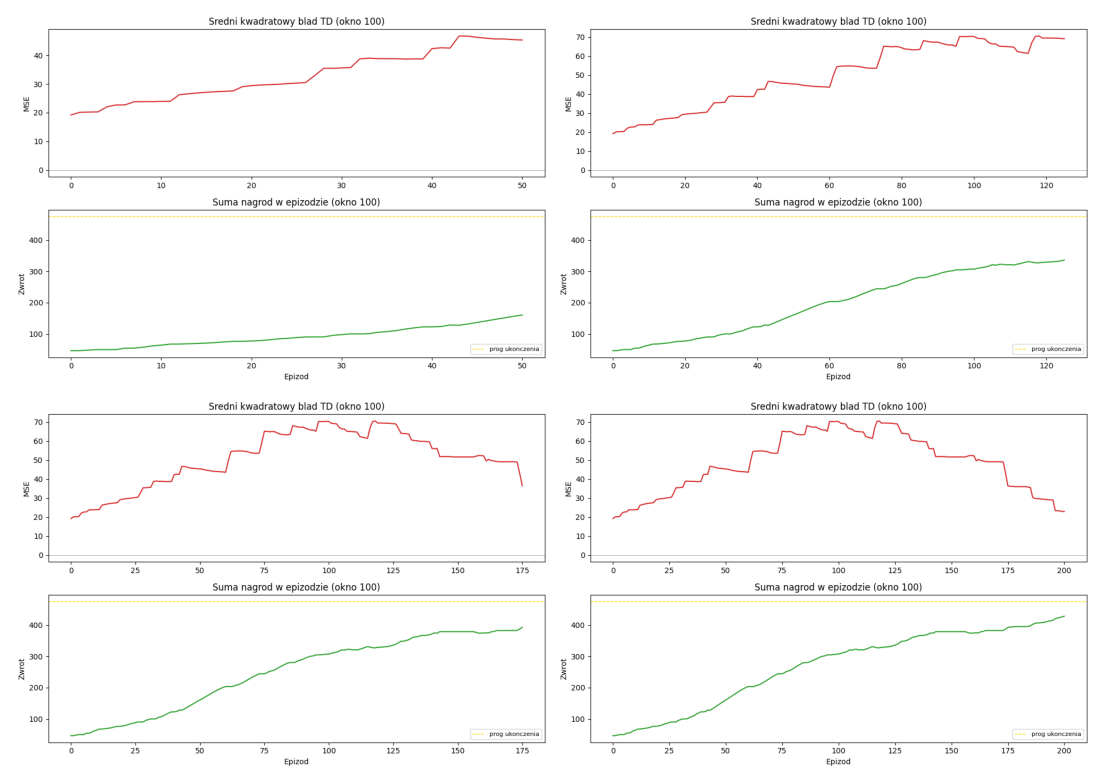

In [37]:
prefix = "cartpole_single_network/plots_cartpole"

episodes_grid = [
    [150, 225],
    [275, 300],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(14, 10))

#### Architektura z rozłącznymi wagami


`build_actor_critic_separate` konstruuje model aktor–krytyk tak, że **aktor i krytyk mają osobne dwie warstwy ukryte** (`actor_fc1`→`actor_fc2`→`logits` oraz `critic_fc1`→`critic_fc2`→`value`), wyłącznie od tego samego wejścia `obs`. Nie ma współdzielenia wag między gałęziami — parametrów jest około dwa razy więcej niż przy jednym trzonie; wartości `hidden[0]` i `hidden[1]` oznaczają wyłącznie szerokości kolejnych warstw w każdej ścieżce. Wyjścia to nadal `[logits, value]` (softmax i uczenie odbywają się jak wcześniej w `compute_loss` / `choose_action`).

```python
def build_actor_critic_separate(
    obs_dim: int,
    n_actions: int,
    hidden: tuple[int, int] = (256, 256),
) -> keras.Model:
    """
    Actor-Critic z NIEZALEZNYMI trzonkami — brak wspoldzielonych wag.
    Kazda glowica ma wlasne dwie warstwy ukryte (dwa razy wiecej parametrow).
    """
    obs = keras.Input(shape=(obs_dim,), name="obs")

    xa = keras.layers.Dense(hidden[0], activation="tanh", name="actor_fc1")(obs)
    xa = keras.layers.Dense(hidden[1], activation="tanh", name="actor_fc2")(xa)
    logits = keras.layers.Dense(n_actions, name="logits")(xa)

    xc = keras.layers.Dense(hidden[0], activation="tanh", name="critic_fc1")(obs)
    xc = keras.layers.Dense(hidden[1], activation="tanh", name="critic_fc2")(xc)
    value = keras.layers.Dense(1, name="value")(xc)

    return keras.Model(inputs=obs, outputs=[logits, value], name="ActorCriticSeparate")
```


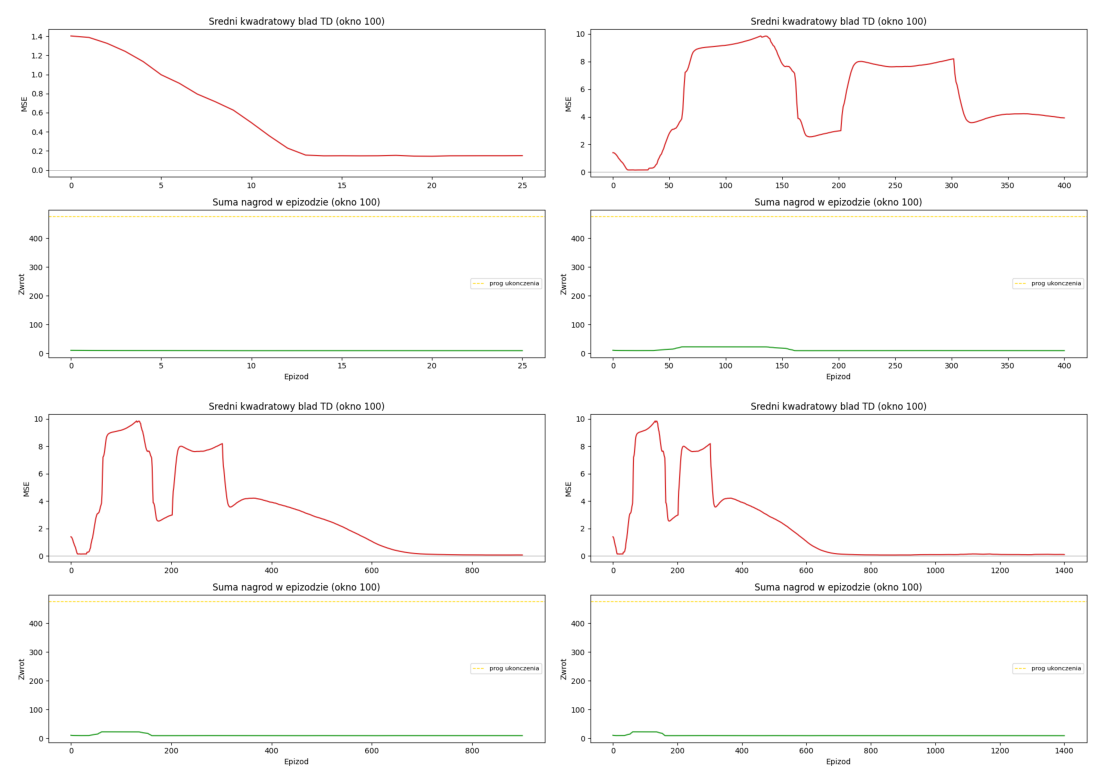

In [38]:
prefix = "cartpole_separate_networks/plots_cartpole"
episodes_grid = [
    [125, 500],
    [1000, 1500],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(14, 10))

### Porównanie modeli: wspólne vs osobne wagi

**Wykresy uczenia.** Dla architektury ze **współdzielonym trzonem** obrazki zapisane podczas treningu pokazują oczekiwany scenariusz: średnia nagroda w oknie rośnie w stronę progu „solved”, a uśredniony błąd TD po początkowych fluktuacjach się ustala — widać, że **polityka i wartościowanie „doganiają” problem**.

Dla **osobnych wag** (rozłączne `actor_fc*` / `critic_fc*`) zaprezentowane siatki PNG z analogicznego eksperymentu **nie pokazują** takiego postępu: krzywe pozostają na poziomie typowym dla słabego agenta (niska średnia zwrotu, brak wyraźnego trendu do 475). W praktyce oznacza to, że w **tym przebiegu** model **nie osiągnął sensownej nauki** w limicie epizodów i przy użytych hiperparametrach — zamiast subtelnej „innej skali” krytyka mamy raczej **niewytrenowany** krytyk i aktora utrzymanych w okolicy startowej dynamiki.

**Co mogło na to wpłynąć (ogólnie):** nagroda +1 za każdy żywy krok, dyskont γ=0.99, **bootstrap TD** (czy krytyk jest skalibrowany do własnych prognoz), **rozkład stanów** generowany przez politykę podczas treningu oraz **ograniczenia sieci MLP** (uśrednianie sąsiadujących stanów w przestrzeni 4D). To nadal **szacunek polityczny** V^π, nie musi idealnie pokrywać się z intuicją „punkt po punkcie”, ale hierarchia (wysokie przy stabilnym pionie, niskie przy groźnym obrotem) jest spójna z CartPole.

**Wniosek:** różnica nie jest tylko kosmetyczna — **porównanie figur i liczb V(s)** wskazuje na udany trening przy wspólnym trzonie i nieudany (w sensie braku „solved” i sensownego V) przy rozdzielonych wagach *w tych konkretnych uruchomieniach*; rozdzielenie architektury mogłoby zadziałać przy innym seedzie, liczbie epizodów lub strojeniu α, ale tu efekt jest jednoznaczny.

**Test krytyka (`--check-critic`).** 

```powershell
python solution.py --env cartpole --check-critic cartpole_single_network\cartpole_final.keras
python solution.py --env cartpole --check-critic cartpole_separate_networks\cartpole_final.keras
```

Wyjście na ręcznie dobranych stanach z `CRITIC_PROBE_STATES` (CartPole — ten sam wektor `s` dla obu modeli):

| Stan | `cartpole_single_network` V(s) | `cartpole_separate_networks` V(s) |
|------|--------------------------------:|----------------------------------:|
| Pion, zerowe prędkości (środek) | 99.99 | 8.70 |
| Szybkie przechylenie (duża prędkość kątowa) | 13.15 | 0.09 |
| Wózek blisko prawej krawędzi (x ≈ +2.35) | 38.35 | 6.76 |
| Wózek blisko lewej krawędzi (x ≈ −2.35) | 97.16 | 9.36 |
| Pochylony pręt, spokojny wózek | 99.99 | 10.33 |

Wyniki na tych samych wektorach stanu potwierdzają ten podział: checkpoint ze **wspólnym trzonem** zwraca V(s) rzędu dziesiątek–ponad sto dla stanów bliskich równowadze — zgodnie z intuicją „dobrego” wartościowania po nauce balansowania. Checkpoint z **osobnymi trzonami** daje **jednocyfrowe** V(s) na większości próbek (np. środek ~8.7 zamiast ~100; stan niebezpiecznego przechyłu ~0.09), co wygląda na **brak dopasowania** funkcji wartości do faktycznych zwrotów — zgodnie z obrazem z wykresów, że uczenie się nie domknęło.

**Wnioski — tylko `cartpole_single_network` (V(s) z `check_critic`, model `cartpole_final.keras`).**  
Krytyk szacuje **oczekiwany zdyskontowany zwrot** przy polityce, na której był trenowany (one-step TD); liczby poniżej odnoszą się wyłącznie do tego checkpointu, nie do optymalnej V*.

- **Pion, zerowe prędkości, V ≈ 99.99:** Stan bliski startu / równowagi — z takiego położenia nauczony agent długo utrzymuje kijek, więc suma nagród (i jej dyskont) może zbliżać się do górnego sensownego rzędu wielkości (maks. ~500 kroków × +1, przy bootstrappingu V bywa ~rząd 10¹–10² w zależności od γ i końca epizodu). Wysoka wartość oznacza: *z tego stanu, kontynuując bieżącą politykę, średnio da się jeszcze „odebrać” bardzo dużo nagrody*.

- **Szybkie przechylenie, duża prędkość kątowa, V ≈ 13.15:** Silnie **ryzykowna** dynamika — z dużym prawdopodobieństwem szybki upadek, mało pozostałych kroków z +1. Krytyk, widząc w danych treningowych liczne przejścia do terminala z podobnych konfiguracji, obniża V: *niewielu „dobrych” trajektorii* z tego stanu w próbce uczenia.

- **Wózek przy prawej krawędzi (x ≈ +2.35), V ≈ 38.35:** Ekstremalna pozycja — większe ryzyko utraty kontroli lub końca epizodu przy mało miejsca na korektę. Wartość **średnia** między „dobrym” centrum a stanami katastrofy; dokładna liczba zależy też od tego, jak często π odwiedzała ten rejon i jak sieć **generalizuje** poza środek przestrzeni stanów.

- **Wózek przy lewej krawędzi (x ≈ −2.35), V ≈ 97.16:** Nadal bardzo wysoko — w zebranych trajektoriach agent mógł **często wracać** z lewej strony bez natychmiastowego końca epizodu, więc krytyk uczy się wysokiego zwrotu także przy dużym |x| po tej stronie (efekt **rozkładu odwiedzanych stanów** i gładkiej aproksymacji; asymetria względem prawej krawędzi może wynikać z konkretnego seeda i polityki).

- **Pochylony pręt, spokojny wózek (kąt ~0.12 rad, prędkości zerowe), V ≈ 99.99:** Małe odchylenie od pionu przy braku impetu — podobnie jak idealny pion, epizod może jeszcze długo trwać; V pozostaje **blisko stanu centralnego**, bo dynamika jest łagodna.